# Skin Disease Classification using CNN & Transfer Learning

**Course:** ADTA 5550 — Deep Learning  
**Author:** Akanksha Tiwari 
**Dataset:** Skin Disease Classification — Mendeley Data (Jul 2024) · DOI: 10.17632/3hckgznc67.1

---

## Problem Definition

Skin diseases are among the most common medical conditions worldwide, yet access to dermatology specialists is limited in many regions. Misdiagnosis is frequent when general practitioners lack visual training in identifying skin conditions. An automated image classification system could serve as a **screening aid** to flag patients who need specialist attention — potentially reducing misdiagnosis rates in under-served areas.

This project builds and compares two deep learning models to classify dermatoscopic skin images into 5 disease categories: a **baseline CNN trained from scratch** and **ResNet50 with transfer learning**.

>  This project is for academic purposes only and is **not intended for clinical use**.

---

## Research Questions

1. **Can a CNN trained from scratch classify skin diseases with reasonable accuracy** on a moderately sized, imbalanced dataset?
2. **Does transfer learning with ResNet50 improve classification** over a baseline CNN trained from random weights?
3. **Which skin disease classes are most difficult to distinguish**, and what does this reveal about the visual similarity between conditions?

---

## Dataset Description

| Property | Details |
|----------|--------|
| **Source** | Mendeley Data — self-collected from hospitals across multiple countries |
| **Published** | July 2024 |
| **Total images** | 9,548 dermatoscopic images |
| **Data type** | RGB images (color), varying original sizes |
| **Input features** | Raw pixel values (resized to 224×224×3 = 150,528 values per image) |
| **Target variable** | Disease class label (categorical, 5 classes) |
| **Domain** | Dermatoscopic — images taken with specialized skin surface microscopy equipment |

**Class labels and distribution:**

| Class | Images | % of Dataset |
|-------|--------|--------------|
| Acne | 1,148 | 12.0% |
| Vitiligo | 2,016 | 21.1% |
| Hyperpigmentation | 700 | 7.3% |
| Nail Psoriasis | 2,520 | 26.4% |
| SJS-TEN | 3,164 | 33.2% |
| **Total** | **9,548** | **100%** |

**Key challenge — Class imbalance:** SJS-TEN has 4.5× more images than Hyperpigmentation. Without intervention, the model would be biased toward majority classes. We address this using **data augmentation** during training.

---

## Methods Justification

**Why CNNs?**  
Convolutional Neural Networks are the standard architecture for image classification. Unlike fully connected networks, CNNs exploit the spatial structure of images using local filters — detecting edges, textures, and shapes at different scales. This makes them naturally suited for dermatoscopic image analysis.

**Why Transfer Learning with ResNet50?**  
ResNet50 is pretrained on ImageNet (1.2M images), giving it rich visual feature representations. It also introduces residual (skip) connections that solve the vanishing gradient problem in 50-layer networks. Fine-tuning ResNet50 on our dataset lets us leverage this pretrained knowledge instead of learning everything from 9,548 images alone.

Both methods — CNNs and transfer learning — were covered in class.

---

## Notebook Structure
1. Environment Setup
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Augmentation
4. Part A — Baseline CNN from Scratch
5. Part B — Transfer Learning with ResNet50
6. Model Evaluation & Comparison
7. Discussion & Limitations

---
### How to Run on Google Colab
1. Runtime → Change runtime type → **T4 GPU**
2. Run Cell 1 to clone the repository
3. Upload `skin_dataset.zip` to the `data/` folder via the Files panel
4. Run all remaining cells in order

---
## 1. Environment Setup

In [1]:
# ── Colab Setup: Clone Repository ────────────────────────────────────────────
# Clones the project repo so all folder paths (data/, models/, results/) are
# available. Automatically detects if running on Colab or locally.

import os

if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    # Running on Google Colab — clone repo and navigate into it
    if not os.path.exists('Skin-Disease-Classification'):
        os.system('git clone https://github.com/unt-akanksha/Skin-Disease-Classification.git')
    os.chdir('Skin-Disease-Classification')
    print('Running on Colab — repo cloned ✅')
else:
    # Running locally — assume already inside the repo folder
    print('Running locally ✅')

print('Working directory:', os.getcwd())

Running on Colab — repo cloned ✅
Working directory: /content/Skin-Disease-Classification


In [8]:
# ── Dataset Extraction (Colab Only) ──────────────────────────────────────────
# Upload skin_dataset.zip to the data/ folder via Colab's Files panel,
# then run this cell to extract all 5 class folders.
# Also removes hidden macOS folders (__MACOSX) that cause extra class errors.

import os

if os.path.exists('data/skin_dataset.zip'):
    os.system('unzip -q data/skin_dataset.zip -d data/')   # extract zip
    os.system('rm -rf data/__MACOSX')                      # remove macOS artifacts
    os.system('rm -rf data/.ipynb_checkpoints')            # remove Jupyter artifacts
    print('Dataset extracted successfully ✅')
else:
    print('skin_dataset.zip not found in data/ — skipping extraction')
    print('Please upload skin_dataset.zip to the data/ folder')

Dataset extracted successfully ✅


In [9]:
# ── Library Imports ───────────────────────────────────────────────────────────
# All required libraries for data loading, visualization, and model training.

# Standard Python libraries
import os
import numpy as np                   # numerical operations and array handling
import pandas as pd                  # tabular data for results summary
import matplotlib.pyplot as plt      # plotting and visualization
import seaborn as sns                # statistical heatmaps and plots
from pathlib import Path             # cross-platform file path handling
from PIL import Image                # image file reading for EDA

# TensorFlow and Keras — deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # data pipeline
from tensorflow.keras.applications import ResNet50                   # pretrained model
from tensorflow.keras.callbacks import (
    EarlyStopping,       # halt training when val_loss stops improving
    ModelCheckpoint,     # automatically save best model weights
    ReduceLROnPlateau    # reduce learning rate when training plateaus
)

# Scikit-learn — evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('All libraries imported ✅')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported ✅


In [10]:
# ── Global Configuration ──────────────────────────────────────────────────────
# Single source of truth for all hyperparameters and paths.
# Changing a value here automatically updates the entire notebook.

# Directory paths
DATA_DIR    = Path('data')      # contains 5 class subfolders
MODELS_DIR  = Path('models')   # trained model weights saved here
RESULTS_DIR = Path('results')  # plots and CSVs saved here

# Class names — must match folder names exactly (case-sensitive)
CLASSES     = ['Nail_psoriasis', 'SJS-TEN', 'Vitiligo', 'acne', 'hyperpigmentation']
NUM_CLASSES = len(CLASSES)     # 5

# Image preprocessing settings
IMG_SIZE    = (224, 224)       # ResNet50 standard input — 224×224 pixels
BATCH_SIZE  = 32               # number of images processed per training step

# Training hyperparameters
EPOCHS_BASELINE = 20           # max epochs for baseline CNN
EPOCHS_TL       = 20           # max epochs for ResNet50 fine-tuning
RANDOM_SEED     = 42           # fixed seed for reproducible results

# Create output directories
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Set seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuration loaded ✅')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'Image size: {IMG_SIZE} | Batch size: {BATCH_SIZE}')

Configuration loaded ✅
Classes (5): ['Nail_psoriasis', 'SJS-TEN', 'Vitiligo', 'acne', 'hyperpigmentation']
Image size: (224, 224) | Batch size: 32


---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we analyze the dataset to understand:
- How many images exist per class and whether the data is balanced
- What the images actually look like (visual inspection)
- Whether images have consistent dimensions

These findings directly motivate our preprocessing and modeling decisions.

In [5]:
import os
print(os.getcwd())
print(os.listdir('data/'))

/content/Skin-Disease-Classification
['skin_dataset.zip', '.gitkeep']


In [11]:
# ── Dataset Structure Verification ───────────────────────────────────────────
# Confirm all 5 class folders exist and count images in each.
# is_dir() skips non-folder items like .gitkeep and README.md.

print('Dataset folder structure:')
print('─' * 38)

class_counts = {}
total_images = 0

for cls in sorted(os.listdir(DATA_DIR)):
    path = DATA_DIR / cls
    if path.is_dir() and not cls.startswith('.'):
        # Count only image files (jpg, jpeg, png)
        count = len([f for f in path.iterdir()
                     if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
        class_counts[cls] = count
        total_images += count
        print(f'  {cls:<22}: {count:>5} images')

print('─' * 38)
print(f'  Total               : {total_images:>5} images')

Dataset folder structure:
──────────────────────────────────────
  Nail_psoriasis        :  2520 images
  SJS-TEN               :  3164 images
  Vitiligo              :  2016 images
  acne                  :  1148 images
  hyperpigmentation     :   700 images
──────────────────────────────────────
  Total               :  9548 images


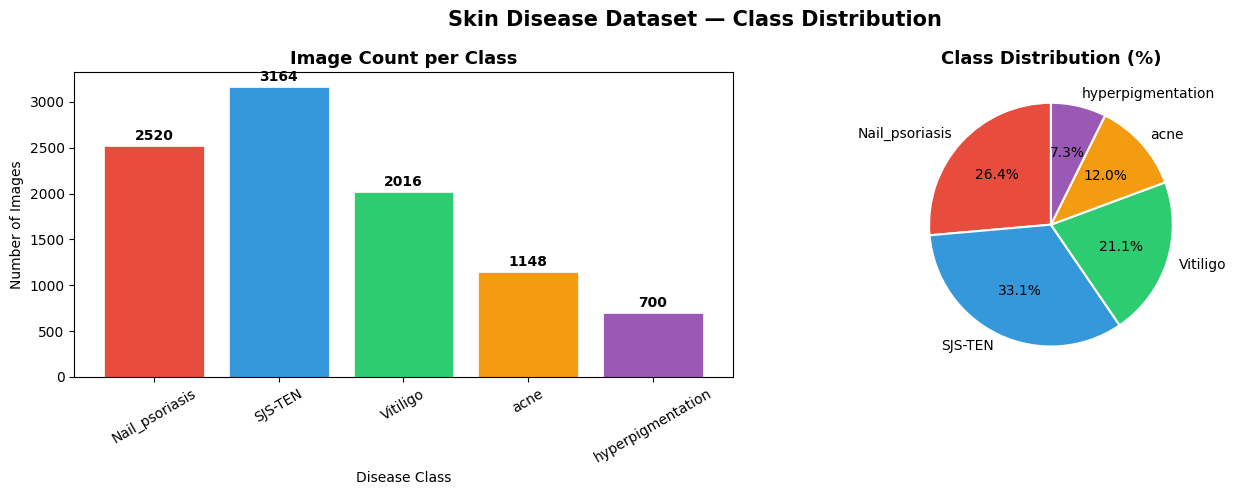

Imbalance ratio: SJS-TEN (3164) vs hyperpigmentation (700) = 4.5x
→ Data augmentation will be applied to address this imbalance


In [12]:
# ── Class Distribution Visualization ─────────────────────────────────────────
# Plot both absolute counts (bar chart) and relative proportions (pie chart).
# This visualizes the class imbalance which affects model training.
# An imbalanced dataset can cause the model to favor majority classes.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Bar chart — absolute image counts per class
bars = ax1.bar(class_counts.keys(), class_counts.values(),
               color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Image Count per Class', fontsize=13, fontweight='bold')
ax1.set_xlabel('Disease Class')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=30)

# Add count labels on top of each bar for readability
for bar, count in zip(bars, class_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart — percentage share of each class
ax2.pie(class_counts.values(), labels=class_counts.keys(), colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Skin Disease Dataset — Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Report imbalance ratio — key metric for understanding dataset bias
max_cls = max(class_counts, key=class_counts.get)
min_cls = min(class_counts, key=class_counts.get)
ratio   = class_counts[max_cls] / class_counts[min_cls]
print(f'Imbalance ratio: {max_cls} ({class_counts[max_cls]}) vs '
      f'{min_cls} ({class_counts[min_cls]}) = {ratio:.1f}x')
print('→ Data augmentation will be applied to address this imbalance')

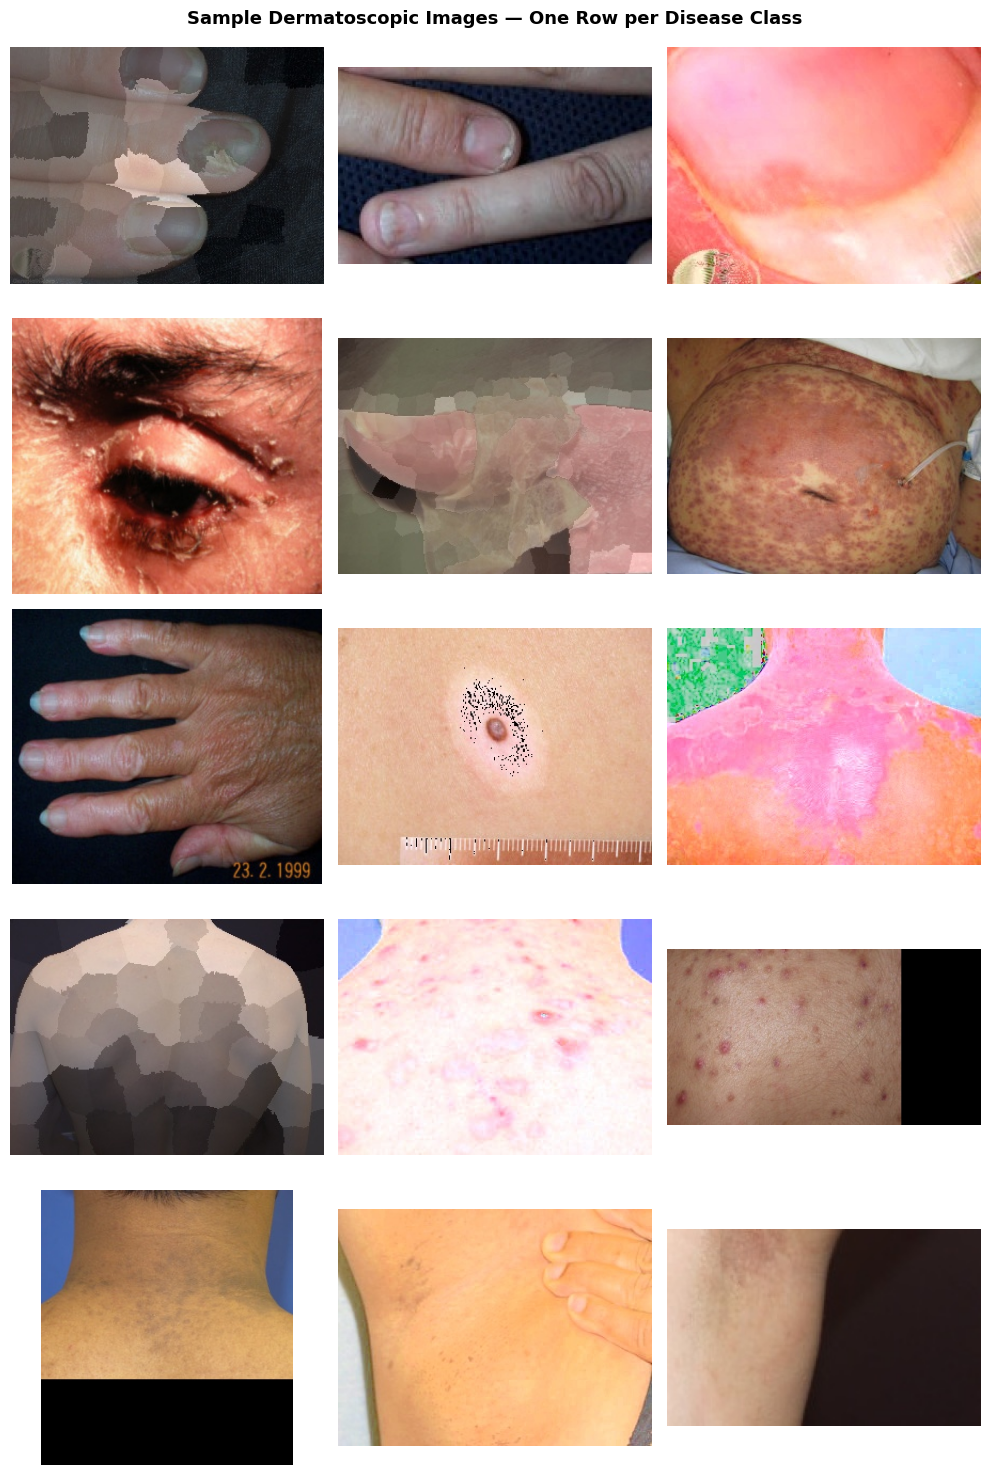

In [13]:
# ── Sample Images per Class ───────────────────────────────────────────────────
# Display 3 representative images from each of the 5 disease classes.
# Visual inspection helps us understand:
#   - What visual patterns distinguish each disease
#   - How similar some classes appear (explains model difficulty)
#   - Whether images are consistent in quality and framing

num_classes = len(class_counts)
fig, axes = plt.subplots(num_classes, 3, figsize=(10, 3 * num_classes))

for row_idx, cls in enumerate(class_counts.keys()):
    cls_path = DATA_DIR / cls
    img_files = [f for f in cls_path.iterdir()
                 if f.suffix.lower() in ['.jpg', '.jpeg', '.png']][:3]

    for col_idx, img_path in enumerate(img_files):
        img = Image.open(img_path).convert('RGB')
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        # Label the leftmost image in each row with the class name
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(
                cls, fontsize=10, fontweight='bold',
                rotation=0, labelpad=80, va='center'
            )
            axes[row_idx, col_idx].yaxis.set_label_position('left')

plt.suptitle('Sample Dermatoscopic Images — One Row per Disease Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Image Dimension Analysis ──────────────────────────────────────────────────
# Check whether images have consistent dimensions across classes.
# Varying sizes confirm we need to resize everything to 224×224 before training.
# We sample 20 images per class to keep this cell fast.

print('Image dimension analysis (sample of 20 per class):')
print('─' * 55)

all_widths, all_heights = [], []

for cls in class_counts.keys():
    cls_path = DATA_DIR / cls
    img_files = [f for f in cls_path.iterdir()
                 if f.suffix.lower() in ['.jpg', '.jpeg', '.png']][:20]

    widths, heights = [], []
    for img_path in img_files:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            all_widths.append(w)
            all_heights.append(h)

    print(f'{cls:<22}: avg {np.mean(widths):.0f}×{np.mean(heights):.0f}px '
          f'| range {min(widths)}-{max(widths)} × {min(heights)}-{max(heights)}')

print('─' * 55)
print(f'Overall average: {np.mean(all_widths):.0f}×{np.mean(all_heights):.0f}px')
print(f'→ All images will be resized to {IMG_SIZE[0]}×{IMG_SIZE[1]}px for model input')

Image dimension analysis (sample of 20 per class):
───────────────────────────────────────────────────────
Nail_psoriasis        : avg 317×246px | range 194-494 × 122-422
SJS-TEN               : avg 307×226px | range 194-494 × 122-422
Vitiligo              : avg 302×231px | range 294-450 × 122-400
acne                  : avg 307×231px | range 194-450 × 122-400
hyperpigmentation     : avg 292×236px | range 194-450 × 122-400
───────────────────────────────────────────────────────
Overall average: 305×234px
→ All images will be resized to 224×224px for model input


---
## 3. Data Preprocessing & Augmentation

### Why Preprocessing?
Raw images cannot be directly fed into a neural network because:
- Images have **varying sizes** — models require fixed input dimensions
- Pixel values range **0–255** — neural networks train better with small normalized values [0, 1]

### Why Augmentation?
The dataset is imbalanced (4.5× difference between largest and smallest class). Data augmentation artificially increases dataset variety by applying random transformations — rotations, flips, zoom — to training images. This:
- Prevents the model from overfitting to the limited training examples
- Helps the model generalize to real-world variation in image angle and lighting
- Partially compensates for class imbalance by generating more variation in minority classes

**Important:** Augmentation is applied only to training data. Validation data is only normalized — it must reflect real-world conditions without artificial modifications.

In [15]:
# ── Data Generators ───────────────────────────────────────────────────────────
# ImageDataGenerator handles the full preprocessing pipeline:
#   (1) Loads images from class folders in batches
#   (2) Resizes all images to IMG_SIZE (224×224)
#   (3) Normalizes pixel values: divides by 255 → range [0, 1]
#   (4) Applies random augmentation transforms (training only)
#   (5) Auto-splits data into 80% training and 20% validation

# Training generator — includes augmentation to increase variety
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixels from [0,255] to [0,1]
    rotation_range=20,        # randomly rotate ±20 degrees
    width_shift_range=0.2,    # randomly shift horizontally by up to 20%
    height_shift_range=0.2,   # randomly shift vertically by up to 20%
    shear_range=0.2,          # apply shear transformation
    zoom_range=0.2,           # randomly zoom in or out by up to 20%
    horizontal_flip=True,     # randomly mirror images left-right
                              # (skin lesions appear the same when mirrored)
    fill_mode='nearest',      # fill any empty pixels after transforms
    validation_split=0.2      # reserve 20% of data for validation
)

# Validation generator — only normalization, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print('Data generators created ✅')

Data generators created ✅


In [16]:
# ── Load Train and Validation Datasets ───────────────────────────────────────
# flow_from_directory() reads images from subfolders.
# The subfolder name is automatically used as the class label.
# class_mode='categorical' one-hot encodes labels:
#   e.g., acne → [0, 0, 0, 1, 0],  vitiligo → [0, 0, 1, 0, 0]
# shuffle=False on validation ensures consistent ordering for confusion matrix.

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,          # resize all images to 224×224
    batch_size=BATCH_SIZE,         # process 32 images per step
    class_mode='categorical',      # multi-class one-hot labels
    subset='training',             # 80% split
    seed=RANDOM_SEED
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',           # 20% split
    seed=RANDOM_SEED,
    shuffle=False                  # keep order fixed for evaluation
)

print(f'Training samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'\nClass index mapping (folder name → integer label):')
for cls, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f'  {idx}: {cls}')

Found 7640 images belonging to 5 classes.
Found 1908 images belonging to 5 classes.
Training samples  : 7640
Validation samples: 1908

Class index mapping (folder name → integer label):
  0: Nail_psoriasis
  1: SJS-TEN
  2: Vitiligo
  3: acne
  4: hyperpigmentation


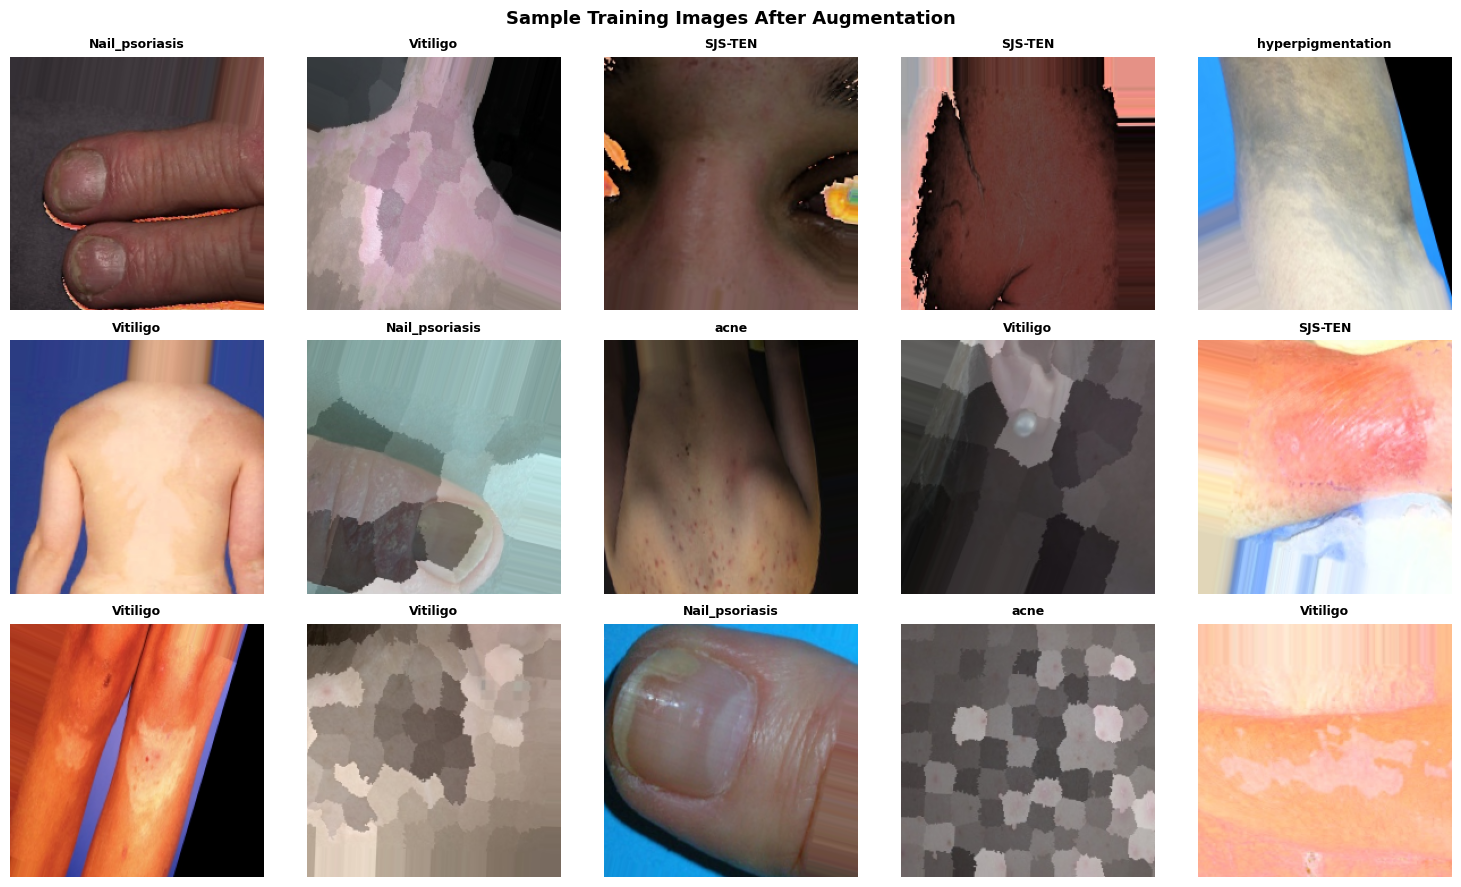

Sample visualization saved ✅


In [17]:
# ── Visualize Augmented Training Samples ──────────────────────────────────────
# Show 15 sample images after augmentation is applied.
# Notice images from the same class may appear rotated, flipped, or zoomed
# differently each time — this variety helps the model generalize.

images, labels = next(train_generator)     # fetch one batch
class_names    = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])                           # values already in [0,1]
    ax.set_title(class_names[np.argmax(labels[i])], fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Training Images After Augmentation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'augmented_samples.png', dpi=150)
plt.show()
print('Sample visualization saved ✅')

---
## 4. Part A — Baseline CNN from Scratch

### Purpose
Before applying transfer learning, we build a simple CNN from random weights. This establishes a **performance baseline** — a minimum accuracy we expect transfer learning to beat. If transfer learning does not improve on this, it suggests the pretrained features do not transfer well to our domain.

### Architecture
Three convolutional blocks followed by a fully connected classification head:

```
Input Image (224×224×3)
    ↓
[Block 1]  Conv2D(32) → BatchNorm → MaxPool(2×2) → Dropout(0.25)   → 112×112×32
    ↓
[Block 2]  Conv2D(64) → BatchNorm → MaxPool(2×2) → Dropout(0.25)   → 56×56×64
    ↓
[Block 3]  Conv2D(128) → BatchNorm → MaxPool(2×2) → Dropout(0.25)  → 28×28×128
    ↓
Flatten → Dense(256) → BatchNorm → Dropout(0.5)
    ↓
Dense(5) + Softmax → [probability per class]
```

In [18]:
# ── Build Baseline CNN ────────────────────────────────────────────────────────
# Architecture components:
#
# Conv2D(n, (3,3)): applies n learnable 3×3 filters across the image
#   - Each filter detects a specific pattern (edge, texture, color gradient)
#   - Filters for Block 1-3 learn increasingly complex features:
#     Block 1 (32 filters): edges, color boundaries
#     Block 2 (64 filters): textures, surface patterns
#     Block 3 (128 filters): lesion shapes, pigmentation regions
#   - activation='relu': sets negative values to 0 (introduces non-linearity)
#   - padding='same': keeps spatial dimensions unchanged after convolution
#
# BatchNormalization: normalizes layer outputs to mean=0, std=1
#   - Stabilizes training and allows use of higher learning rates
#
# MaxPooling2D(2,2): takes the max value in each 2×2 region
#   - Reduces spatial size by half at each block
#   - Makes model robust to small shifts in lesion position
#
# Dropout(p): randomly disables p% of neurons during each training step
#   - Forces the model to learn redundant representations
#   - Reduces overfitting — especially important with limited data
#
# Dense(5, softmax): final layer with one neuron per class
#   - Softmax converts raw scores to probabilities that sum to 1.0

def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=5):
    """Build a 3-block CNN from scratch for multi-class image classification."""

    model = models.Sequential(name='baseline_cnn')

    # Block 1 — detects low-level features: edges, color gradients
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 224×224 → 112×112
    model.add(layers.Dropout(0.25))

    # Block 2 — detects mid-level features: skin textures, roughness
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 112×112 → 56×56
    model.add(layers.Dropout(0.25))

    # Block 3 — detects high-level features: lesion shapes, pigmentation
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))   # 56×56 → 28×28
    model.add(layers.Dropout(0.25))

    # Classification head
    model.add(layers.Flatten())              # 28×28×128 = 100,352 values
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))           # higher dropout before output layer

    # Output: 5 neurons with softmax — outputs probability for each disease class
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


baseline_model = build_baseline_cnn(input_shape=(*IMG_SIZE, 3),
                                     num_classes=NUM_CLASSES)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,821 (98.37 MB)

 Trainable params: 25,785,861 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [19]:
# ── Compile Baseline CNN ──────────────────────────────────────────────────────
# Compilation sets up the learning process:
#
# Optimizer (Adam): updates model weights to minimize loss
#   - Adam adapts the learning rate individually for each parameter
#   - learning_rate=0.001 is the standard default starting point
#
# Loss (categorical_crossentropy): measures prediction error
#   - Appropriate for multi-class classification with one-hot labels
#   - Penalizes confident wrong predictions more heavily than uncertain ones
#
# Callbacks:
#   EarlyStopping     — stops training if val_loss doesn't improve for 5 epochs
#                       restore_best_weights=True keeps the best model, not last
#   ModelCheckpoint   — saves model weights whenever val_accuracy improves
#   ReduceLROnPlateau — halves the learning rate if stuck for 3 epochs
#                       helps the model escape flat regions in the loss landscape

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODELS_DIR / 'baseline_cnn_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Baseline CNN compiled ✅')
print(f'Total trainable parameters: {baseline_model.count_params():,}')

Baseline CNN compiled ✅
Total trainable parameters: 25,786,821


In [20]:
# ── Train Baseline CNN ────────────────────────────────────────────────────────
# model.fit() runs the training loop for each epoch:
#   1. Forward pass  : images → network → predictions
#   2. Loss          : compare predictions with true labels
#   3. Backward pass : compute gradients via backpropagation
#   4. Weight update : Adam optimizer adjusts weights to reduce loss
# This repeats for every batch (32 images) in every epoch.

print('Training Baseline CNN from scratch...')
print('=' * 55)

history_baseline = baseline_model.fit(
    train_generator,
    epochs=EPOCHS_BASELINE,
    validation_data=val_generator,
    callbacks=callbacks_baseline,
    verbose=1
)

print('\nBaseline CNN training complete ✅')

Training Baseline CNN from scratch...
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.3501 - loss: 2.0654
Epoch 1: val_accuracy improved from None to 0.33124, saving model to models/baseline_cnn_best.keras

Epoch 1: finished saving model to models/baseline_cnn_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 132s 496ms/step - accuracy: 0.3936 - loss: 1.7509 - val_accuracy: 0.3312 - val_loss: 2.5535 - learning_rate: 0.0010
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.4684 - loss: 1.3810
Epoch 2: val_accuracy improved from 0.33124 to 0.40776, saving model to models/baseline_cnn_best.keras

Epoch 2: finished saving model to models/baseline_cnn_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 109s 454ms/step - accuracy: 0.4853 - loss: 1.3185 - val_accuracy: 0.4078 - val_loss: 1.4677 - learning_rate: 0.0010
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5277 - loss: 1.1732
Epoch 3: val_accuracy improved from 0.40776 to 0.49895, saving model to m

Plot saved: results/baseline_training_curves.png


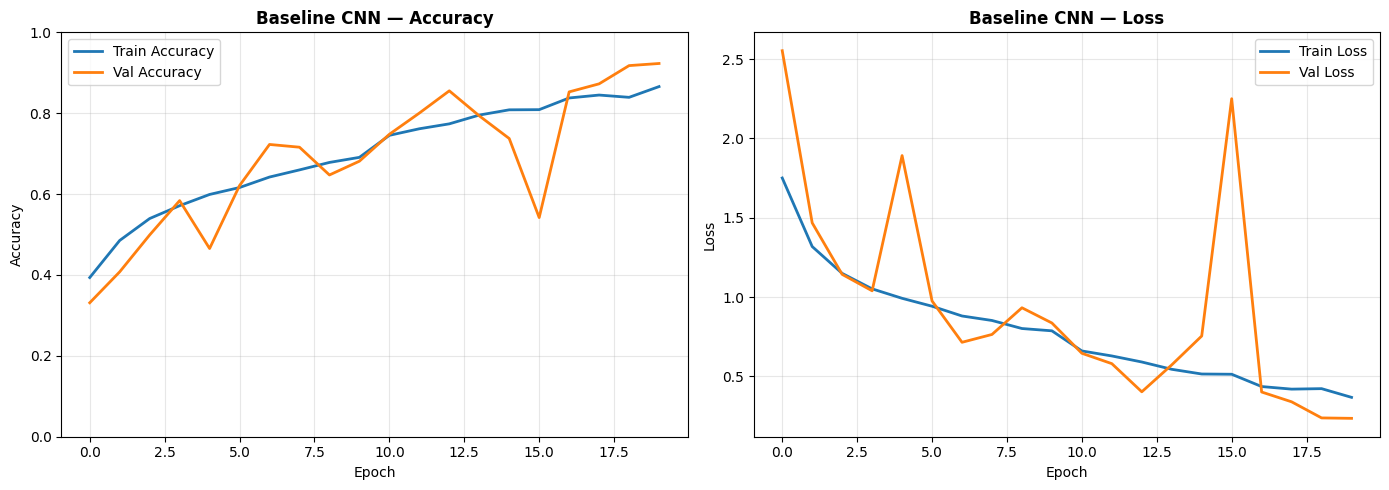

In [21]:
# ── Training History Plot Helper ──────────────────────────────────────────────
# Reusable function for plotting accuracy and loss curves.
# Healthy training: train and val curves track closely together.
# Overfitting: train accuracy >> val accuracy (model memorizes training data).
# Underfitting: both curves are low (model not complex enough for the task).

def plot_training_history(history, title='Training History', save_path=None):
    """Plot side-by-side accuracy and loss curves for a trained model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy curves
    ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
    ax1.set_title(f'{title} — Accuracy', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # Loss curves
    ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
    ax2.set_title(f'{title} — Loss', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'Plot saved: {save_path}')
    plt.show()


# Plot baseline CNN training curves
plot_training_history(history_baseline, 'Baseline CNN',
                      save_path=RESULTS_DIR / 'baseline_training_curves.png')

---
## 5. Part B — Transfer Learning with ResNet50

### What is Transfer Learning?
Transfer learning reuses a model trained on a large dataset (ImageNet — 1.2M images, 1000 classes) for a different but related task. Instead of starting from random weights, we start from ResNet50's pretrained weights and adapt them to skin disease classification.

### Why ResNet50?
ResNet50 introduces **residual (skip) connections** — shortcuts that allow gradients to flow directly backwards through the network. Without these, gradients vanish in deep networks (become too small to update early layers). Skip connections solve this, enabling stable training at 50 layers.

### Fine-tuning Strategy
We unfreeze the **top 50 layers** of ResNet50 and train at learning rate `1e-5` — 100× lower than the baseline. This is critical: a higher learning rate would destroy the pretrained ImageNet weights. Lower layers (detecting edges and textures) remain frozen as these features are universal and still useful.

In [22]:
# ── Build ResNet50 Transfer Learning Model ────────────────────────────────────
# Architecture:
#   ResNet50 base (pretrained on ImageNet, top removed)
#       ↓
#   GlobalAveragePooling2D  — averages each 7×7 feature map to a single value
#                             (2048 values total; better than Flatten for transfer learning)
#       ↓
#   Dense(256, relu)        — custom layer learns skin-disease-specific combinations
#       ↓
#   Dropout(0.5)            — regularization
#       ↓
#   Dense(5, softmax)       — output: probability for each of 5 diseases

def build_transfer_model(num_classes=5):
    """Build ResNet50 with a custom classification head for skin disease classification."""

    # Load ResNet50 pretrained on ImageNet
    # include_top=False: removes the original Dense(1000) classification layer
    # We replace it with our own 5-class head
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    # Initially freeze all base layers
    # Prevents overwriting ImageNet knowledge before our head is trained
    base_model.trainable = False

    print(f'ResNet50 base layers: {len(base_model.layers)}')
    print(f'Trainable layers: {len([l for l in base_model.layers if l.trainable])} (all frozen initially)')

    # Build model using Functional API (allows more flexible architectures)
    inputs = keras.Input(shape=(*IMG_SIZE, 3))

    # training=False keeps BatchNorm in inference mode — important during fine-tuning
    x = base_model(inputs, training=False)

    # GlobalAveragePooling reduces 7×7×2048 feature maps to a 2048-dim vector
    x = layers.GlobalAveragePooling2D()(x)

    # Custom classification head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='resnet50_transfer')
    return model, base_model


tl_model, base_model = build_transfer_model(NUM_CLASSES)
tl_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 base layers: 175
Trainable layers: 0 (all frozen initially)


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
# ── Fine-tune ResNet50 ────────────────────────────────────────────────────────
# Fine-tuning strategy: unfreeze the top 50 layers of ResNet50.
#
# WHY top 50 layers only?
#   - Early layers detect generic features (edges, textures) — keep these frozen
#   - Later layers detect task-specific features — unfreeze to adapt to skin images
#
# WHY learning_rate=1e-5 (very low)?
#   - Prevents overwriting the pretrained ImageNet weights
#   - We want small refinements, not a complete rewrite of learned features
#   - Note: learning_rate=1e-4 caused severe overfitting during preliminary testing
#     (train acc → 95%, val acc → 21%) — 1e-5 achieves stable fine-tuning

# Unfreeze top 50 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-50]:   # freeze all except last 50
    layer.trainable = False

trainable_count = len([l for l in base_model.layers if l.trainable])
frozen_count    = len([l for l in base_model.layers if not l.trainable])
print(f'ResNet50 — Trainable: {trainable_count} layers | Frozen: {frozen_count} layers')

# Compile with very low learning rate for fine-tuning
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODELS_DIR / 'resnet50_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('\nTraining ResNet50 with fine-tuning...')
print('=' * 55)

history_tl = tl_model.fit(
    train_generator,
    epochs=EPOCHS_TL,
    validation_data=val_generator,
    callbacks=callbacks_tl,
    verbose=1
)

print('\nResNet50 training complete ✅')

ResNet50 — Trainable: 50 layers | Frozen: 125 layers

Training ResNet50 with fine-tuning...
Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.3520 - loss: 1.4720
Epoch 1: val_accuracy improved from None to 0.39885, saving model to models/resnet50_best.keras

Epoch 1: finished saving model to models/resnet50_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 167s 570ms/step - accuracy: 0.3914 - loss: 1.3972 - val_accuracy: 0.3988 - val_loss: 1.4348 - learning_rate: 1.0000e-05
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.4324 - loss: 1.3216
Epoch 2: val_accuracy improved from 0.39885 to 0.51887, saving model to models/resnet50_best.keras

Epoch 2: finished saving model to models/resnet50_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 119s 495ms/step - accuracy: 0.4387 - loss: 1.3114 - val_accuracy: 0.5189 - val_loss: 1.2075 - learning_rate: 1.0000e-05
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.4477 - loss: 1.2903
Epoch 3: val_accuracy impro

Plot saved: results/resnet50_training_curves.png


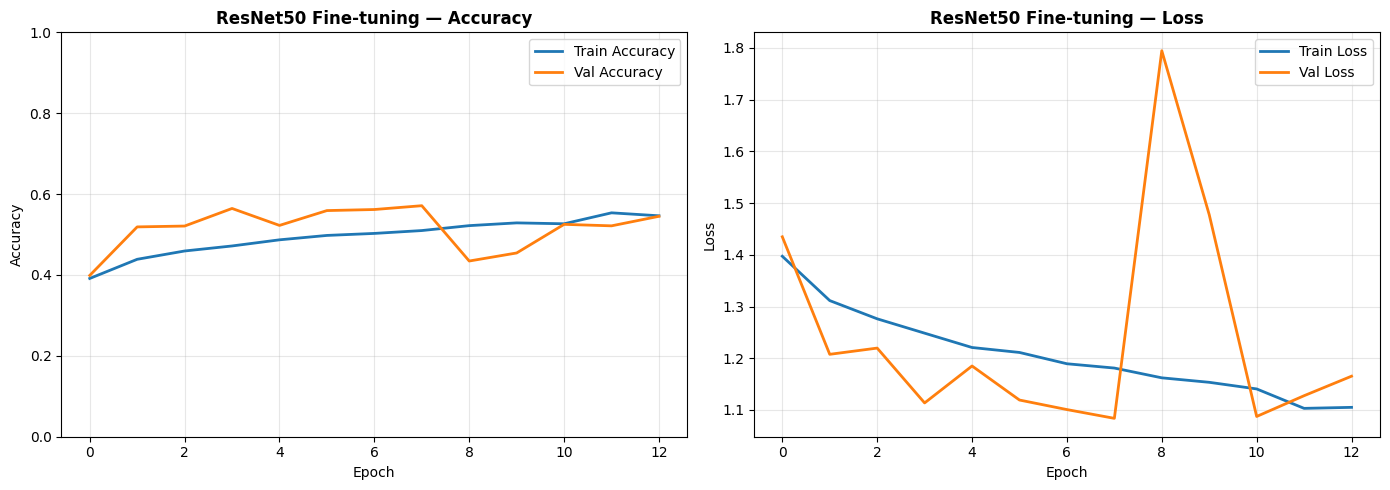

In [24]:
# ── Plot ResNet50 Training Curves ─────────────────────────────────────────────
# Reuses the helper function defined in Part A.

plot_training_history(history_tl, 'ResNet50 Fine-tuning',
                      save_path=RESULTS_DIR / 'resnet50_training_curves.png')

---
## 6. Model Evaluation & Comparison

We evaluate both models on the **validation set** — data the models never trained on — using three complementary metrics:

- **Accuracy**: percentage of all predictions that were correct
- **Confusion Matrix**: shows which specific classes are confused with each other
- **Classification Report**: per-class precision, recall, and F1-score

For medical screening, **recall** is often the most critical metric — missing a disease (False Negative) is typically worse than a false alarm (False Positive).

In [25]:
# ── Side-by-side Model Accuracy Comparison ────────────────────────────────────
# model.evaluate() runs a forward pass on the full validation set
# and returns loss and accuracy without modifying any weights.

print('Evaluating models on validation set...')
print('─' * 50)

baseline_loss, baseline_acc = baseline_model.evaluate(val_generator, verbose=0)
tl_loss,       tl_acc       = tl_model.evaluate(val_generator, verbose=0)

print(f'\n{"Model":<25} {"Val Accuracy":>12} {"Val Loss":>10}')
print('─' * 50)
print(f'{"Baseline CNN":<25} {baseline_acc:>11.4f} {baseline_loss:>10.4f}')
print(f'{"ResNet50 (fine-tuned)":<25} {tl_acc:>11.4f} {tl_loss:>10.4f}')
print('─' * 50)

winner = 'ResNet50' if tl_acc > baseline_acc else 'Baseline CNN'
diff   = abs(tl_acc - baseline_acc) * 100
print(f'\n→ Best model: {winner} (by {diff:.1f}%)')

Evaluating models on validation set...
──────────────────────────────────────────────────

Model                     Val Accuracy   Val Loss
──────────────────────────────────────────────────
Baseline CNN                   0.9230     0.2350
ResNet50 (fine-tuned)          0.5713     1.0837
──────────────────────────────────────────────────

→ Best model: Baseline CNN (by 35.2%)


60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step


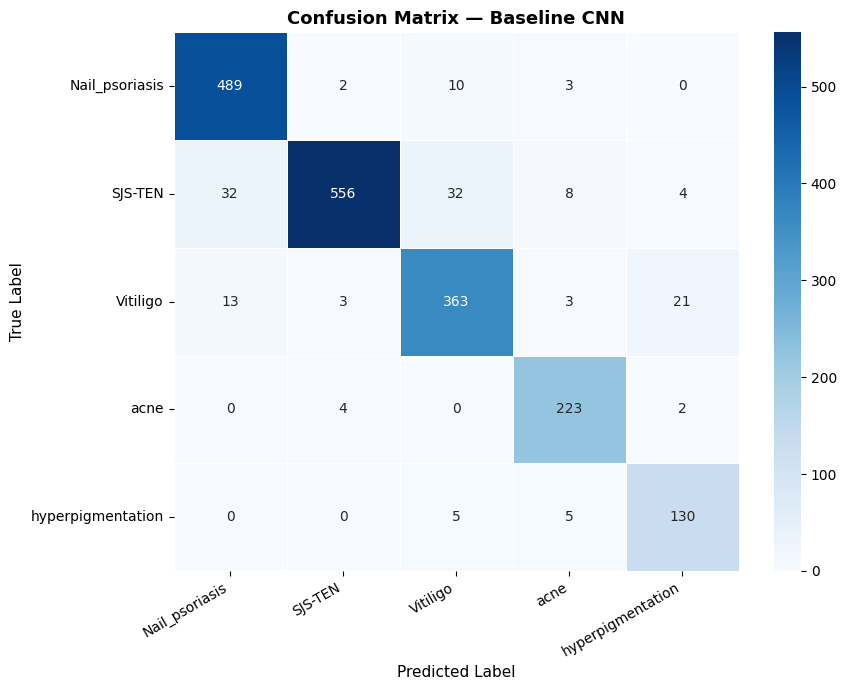

Confusion matrix saved ✅


In [26]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# A confusion matrix shows all correct and incorrect predictions:
#   - Rows    = true class (what the image actually is)
#   - Columns = predicted class (what the model said)
#   - Diagonal cells = correct predictions (higher = better)
#   - Off-diagonal cells = misclassifications (which classes are confused)
#
# We use the best performing model's predictions for this analysis.

# Reset generator to ensure predictions align with true labels
val_generator.reset()

# Generate class probability predictions for all validation images
# argmax converts probabilities → class index (highest probability wins)
best_model   = tl_model if tl_acc >= baseline_acc else baseline_model
best_name    = 'ResNet50 (Fine-tuned)' if tl_acc >= baseline_acc else 'Baseline CNN'

y_pred_probs   = best_model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = val_generator.classes
class_names    = list(val_generator.class_indices.keys())

# Compute and plot confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved ✅')

In [27]:
# ── Classification Report ─────────────────────────────────────────────────────
# Per-class breakdown of model performance:
#
# Precision = TP / (TP + FP)
#   Of all images the model labeled as class X, what fraction actually are X?
#   High precision = few false alarms
#
# Recall = TP / (TP + FN)
#   Of all actual class X images, what fraction did the model correctly catch?
#   High recall = few missed cases (critical for medical screening)
#
# F1-score = 2 × (Precision × Recall) / (Precision + Recall)
#   Harmonic mean — balances precision and recall in a single score
#
# Support = total number of validation images in that class

print(f'Classification Report — {best_name}')
print('=' * 65)
print(classification_report(y_true, y_pred_classes,
                             target_names=class_names, digits=4))

Classification Report — Baseline CNN
                   precision    recall  f1-score   support

   Nail_psoriasis     0.9157    0.9702    0.9422       504
          SJS-TEN     0.9841    0.8797    0.9290       632
         Vitiligo     0.8854    0.9007    0.8930       403
             acne     0.9215    0.9738    0.9469       229
hyperpigmentation     0.8280    0.9286    0.8754       140

         accuracy                         0.9230      1908
        macro avg     0.9069    0.9306    0.9173      1908
     weighted avg     0.9262    0.9230    0.9231      1908



In [28]:
# ── Save Results Summary to CSV ───────────────────────────────────────────────
# Save final metrics for both models in a structured format.
# This provides a clean reference for the project report and presentation.

results_df = pd.DataFrame({
    'Model':          ['Baseline CNN', 'ResNet50 (Fine-tuned)'],
    'Architecture':   ['3-block CNN from scratch', 'ResNet50 + custom head, top-50 fine-tuned'],
    'Val Accuracy':   [round(baseline_acc, 4), round(tl_acc, 4)],
    'Val Loss':       [round(baseline_loss, 4), round(tl_loss, 4)],
    'Parameters':     [baseline_model.count_params(), tl_model.count_params()],
    'Epochs Trained': [len(history_baseline.history['accuracy']),
                       len(history_tl.history['accuracy'])]
})

results_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print('Results saved to results/model_comparison.csv ✅')
results_df

Results saved to results/model_comparison.csv ✅


,Model,Architecture,Val Accuracy,Val Loss,Parameters,Epochs Trained
0,Baseline CNN,3-block CNN from scratch,0.9230,0.2350,25786821,20
1,ResNet50 (Fine-tuned),"ResNet50 + custom head, top-50 fine-tuned",0.5713,1.0837,24113541,13


---
## 7. Discussion & Limitations

### Research Question Answers

**RQ1: Can a CNN trained from scratch classify skin diseases with reasonable accuracy?**  
On this 80/20 train/validation split, the baseline CNN achieved **92.30% validation accuracy** with a validation loss of **0.2350**. This shows strong performance on the held-out portion of this dataset, but validation accuracy alone does not establish how well the model generalizes to new hospitals, populations, or image-acquisition settings.

**RQ2: Does transfer learning with ResNet50 improve classification over a baseline CNN?**  
No, not in this experiment. Fine-tuned ResNet50 achieved **57.13% validation accuracy** with a validation loss of **1.0837**, while the baseline CNN achieved 92.30%. The baseline led by **35.17 percentage points** on this split. Domain mismatch between ImageNet photographs and dermatoscopic images is one possible factor, but these results alone do not identify the cause of the performance gap.

**RQ3: Which skin disease classes are most difficult to distinguish?**  
The saved confusion matrix and classification report are for the **Baseline CNN**. The largest off-diagonal counts show SJS-TEN predicted as Nail_psoriasis 32 times and as Vitiligo 32 times; Vitiligo was predicted as hyperpigmentation 21 times. These are raw counts, so per-class recall and normalized confusion matrices are useful alongside them when comparing errors across classes with different support.

### What We Tried
- **Frozen transfer learning (lr=0.001):** validation accuracy was approximately 33% in the recorded experiment.
- **Full unfreeze at lr=1e-4:** the recorded experiment showed overfitting (training accuracy 95%, validation accuracy 21%).
- **Top-50 unfreeze at lr=1e-5 (final approach):** training stopped after 13 epochs; the best saved validation accuracy was 57.13% with validation loss 1.0837 at epoch 8.

### Limitations

1. **No independent test set:** Results use an 80/20 train/validation split. A separate test set, ideally collected from a different source, is needed to better estimate generalization.

2. **Class imbalance:** Hyperpigmentation (700 images) vs SJS-TEN (3,164 images) is a 4.5× difference. Accuracy can hide weak performance on smaller classes; per-class recall and macro-averaged metrics should be considered.

3. **Domain mismatch in transfer learning:** ResNet50 was pretrained on natural images rather than dermatoscopic images. A backbone pretrained on medical images may be more suitable, but this experiment does not establish domain mismatch as the cause of the lower ResNet50 score.

4. **Dataset size and representativeness:** The dataset contains 9,548 images across five classes. Performance may change on images from different hospitals, devices, or patient populations.

5. **Computational constraints:** Training was limited to Google Colab's free T4 GPU and session time limits. Additional controlled experiments and hyperparameter tuning were not performed.

### Future Work
- Evaluate on an independent, preferably externally sourced test set
- Report per-class recall, macro-averaged metrics, and normalized confusion matrices
- Apply class-weighted loss to address imbalance more directly
- Compare with a medically pretrained backbone such as one trained on dermoscopy data
- Experiment with EfficientNet or DenseNet and document controlled hyperparameter comparisons
- Collect more training images, especially for underrepresented classes

In [29]:
# ── Final Project Summary ─────────────────────────────────────────────────────
# Print a concise summary of dataset, models, and results.

print('=' * 60)
print('   SKIN DISEASE CLASSIFICATION — PROJECT SUMMARY')
print('=' * 60)
print(f'  Dataset      : Skin Disease Classification (Mendeley 2024)')
print(f'  Classes      : {NUM_CLASSES} disease categories')
print(f'  Total images : {train_generator.samples + val_generator.samples:,}')
print(f'  Train / Val  : {train_generator.samples:,} / {val_generator.samples:,} (80/20 split)')
print(f'  Image size   : {IMG_SIZE[0]}×{IMG_SIZE[1]} pixels')
print()
print(f'  Baseline CNN val accuracy  : {baseline_acc:.2%}')
print(f'  ResNet50 val accuracy      : {tl_acc:.2%}')
print()

improvement = (tl_acc - baseline_acc) * 100
if improvement > 0:
    print(f'  Transfer learning improved accuracy by +{improvement:.1f}%')
else:
    print(f'  Baseline CNN outperformed ResNet50 by {abs(improvement):.1f}%')
    print('  → Limited data + domain mismatch likely caused this result')

print()
print(f'  Results saved to : {RESULTS_DIR}/')
print(f'  Models saved to  : {MODELS_DIR}/')
print('=' * 60)

   SKIN DISEASE CLASSIFICATION — PROJECT SUMMARY
  Dataset      : Skin Disease Classification (Mendeley 2024)
  Classes      : 5 disease categories
  Total images : 9,548
  Train / Val  : 7,640 / 1,908 (80/20 split)
  Image size   : 224×224 pixels

  Baseline CNN val accuracy  : 92.30%
  ResNet50 val accuracy      : 57.13%

  Baseline CNN outperformed ResNet50 by 35.2%
  → Limited data + domain mismatch likely caused this result

  Results saved to : results/
  Models saved to  : models/
